In [43]:
# !git clone https://github.com/Ifthekher237/mq-assignment-2-llm-financial-advice-evaluation.git

In [44]:
!ls -R

.:
sample_data

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [45]:
# %cd /content/mq-assignment-2-llm-financial-advice-evaluation

In [46]:
# %cd codes

In [47]:
#!pwd

# COMP8420 Assignment 2 — LLM Comparison Notebook
## Smart Personal Finance Assistant: Model Evaluation Pipeline

**Assignment Context:**
This notebook fulfils the following rubric requirements:
- Selection and justification of two open-source instruction-tuned LLMs
- Configuration of local pretrained models via HuggingFace Transformers
- Comparison of three distinct prompting strategies (zero-shot, few-shot, structured)
- Systematic evaluation using a multi-dimension scoring framework
- Export of all results for report writing and further analysis

**Models Selected:**
| Model | Architecture | Size | Justification |
|---|---|---|---|
| `google/flan-t5-large` | Seq2Seq (Encoder-Decoder) | ~770M params | Google's instruction-fine-tuned T5; strong on task-directed generation; memory-efficient on Colab free tier |
| `TinyLlama/TinyLlama-1.1B-Chat-v1.0` | Causal Decoder (LLaMA arch) | ~1.1B params | Modern chat-aligned decoder; trained on ShareGPT conversations; represents current RLHF-style instruction tuning |

**Why these two?**
Comparing a seq2seq model (Flan-T5) with a decoder-only chat model (TinyLlama) provides meaningful architectural contrast for academic analysis — they differ in attention mechanism, generation strategy, and training objective, making the comparison methodologically substantive.



In [48]:
# Install required packages
# Run once per Colab session; restart runtime if prompted
!pip install -q transformers accelerate sentencepiece bitsandbytes pandas tqdm

# Verify GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [49]:
import pandas as pd
import numpy as np
import json
import time
import re
import warnings
from datetime import datetime
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    pipeline,
    set_seed,
)

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Using device: {DEVICE} | dtype: {DTYPE}")


Using device: cuda | dtype: torch.float16


## Section 1 — Finance Test Cases Dataset

The dataset contains 15 realistic user profiles covering diverse financial scenarios:
student debt, low-income budgeting, retirement planning, halal/shariah-compliant investing,
high-risk growth investing, mortgage management, and more.

Each case is tagged with a `task_type` label to allow stratified analysis of LLM performance
across different finance task categories.


In [50]:
from google.colab import files
uploaded = files.upload()  # select finance_test_cases.csv
CSV_PATH = list(uploaded.keys())[0]

Saving finance_test_cases.csv to finance_test_cases.csv


In [51]:
# ── Option A: Load from Google Drive (recommended for Colab) ──────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/COMP8420/finance_test_cases.csv'

# ── Option B: Upload directly to Colab session ────────────────────────────────
# from google.colab import files
# uploaded = files.upload()  # select finance_test_cases.csv
# CSV_PATH = list(uploaded.keys())[0]

# ── Option C: Hardcoded path (update as needed) ───────────────────────────────
# CSV_PATH = "finance_test_cases.csv"  # place file in Colab working directory

try:
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded {len(df)} test cases with columns:\n{list(df.columns)}")
    display(df[['case_id','age','employment_status','monthly_income',
                'financial_goal','risk_tolerance','task_type']].head(15))
except FileNotFoundError:
    print(f"ERROR: '{CSV_PATH}' not found. Please upload the CSV file first.")
    raise


Loaded 15 test cases with columns:
['case_id', 'age', 'employment_status', 'monthly_income', 'monthly_expenses', 'current_savings', 'current_debt', 'risk_tolerance', 'financial_goal', 'investment_horizon', 'extra_preferences', 'task_type']


,case_id,age,employment_status,monthly_income,financial_goal,risk_tolerance,task_type
0,TC001,20,student,800,Pay off student debt and build emergency fund,low,debt_management
1,TC002,24,part_time_worker,1500,Build a 3-month emergency fund,low,savings_plan
2,TC003,30,full_time_employed,3800,Save for house deposit in 5 years,moderate,goal_planning
3,TC004,27,freelancer,2200,Eliminate high-interest credit card debt urgently,low,debt_management
4,TC005,45,full_time_employed,7500,Aggressive wealth building via diversified inv...,high,investment_advice
5,TC006,35,full_time_employed,5000,Balance debt repayment with retirement savings,moderate,retirement_planning
6,TC007,55,self_employed,6000,Protect wealth and generate stable income befo...,low,retirement_planning
7,TC008,22,full_time_employed,2800,Start investing for the first time with small ...,moderate,investment_advice
8,TC009,40,full_time_employed,9000,Maximise investment returns while managing mor...,high,investment_advice
9,TC010,33,unemployed,0,Survive on savings and avoid going further int...,low,budgeting


In [52]:
# ── Dataset overview for report evidence ─────────────────────────────────────
print("=== Task Type Distribution ===")
print(df['task_type'].value_counts().to_string())
print("\n=== Risk Tolerance Distribution ===")
print(df['risk_tolerance'].value_counts().to_string())
print("\n=== Age Stats ===")
print(df['age'].describe().round(1).to_string())
print("\n=== Income Stats (AUD/month) ===")
print(df['monthly_income'].describe().round(0).to_string())


=== Task Type Distribution ===
task_type
investment_advice      5
debt_management        3
retirement_planning    3
goal_planning          2
savings_plan           1
budgeting              1

=== Risk Tolerance Distribution ===
risk_tolerance
low         6
moderate    6
high        3

=== Age Stats ===
count    15.0
mean     34.4
std      10.4
min      20.0
25%      26.5
50%      33.0
75%      41.0
max      55.0

=== Income Stats (AUD/month) ===
count      15.0
mean     4220.0
std      2719.0
min         0.0
25%      2350.0
50%      3800.0
75%      6250.0
max      9000.0


## Section 2 — Model Loading & Configuration

Both models are loaded from HuggingFace Hub with the following configurations:

**Flan-T5-Large** (`google/flan-t5-large`)
- Architecture: Encoder-Decoder (seq2seq), ~770M parameters
- Fine-tuning: Instruction-tuned on 1,836 NLP tasks (FLAN collection)
- Generation: `generate()` with `max_new_tokens`, temperature, and beam search

**TinyLlama-1.1B-Chat** (`TinyLlama/TinyLlama-1.1B-Chat-v1.0`)
- Architecture: Decoder-only LLaMA (1.1B parameters, 22 transformer layers)
- Fine-tuning: Chat-aligned using ShareGPT + RLHF-style training
- Generation: Uses ChatML-style conversation template via tokenizer's chat template

Both models use `float16` on GPU and `float32` on CPU for numerical stability.


In [53]:
# ── Model 1: google/flan-t5-large ────────────────────────────────────────────
MODEL1_NAME = "google/flan-t5-large"

print(f"Loading {MODEL1_NAME} ...")
t0 = time.time()

tokenizer1 = AutoTokenizer.from_pretrained(MODEL1_NAME)
model1 = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL1_NAME,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
)
if DEVICE == "cpu":
    model1 = model1.to(DEVICE)

model1.eval()
print(f"Flan-T5-Large loaded in {time.time()-t0:.1f}s")
print(f"Parameters: {sum(p.numel() for p in model1.parameters())/1e6:.0f}M")


Loading google/flan-t5-large ...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Flan-T5-Large loaded in 16.8s
Parameters: 783M


In [54]:
# ── Model 2: TinyLlama/TinyLlama-1.1B-Chat-v1.0 ──────────────────────────────
MODEL2_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {MODEL2_NAME} ...")
t0 = time.time()

tokenizer2 = AutoTokenizer.from_pretrained(MODEL2_NAME)
model2 = AutoModelForCausalLM.from_pretrained(
    MODEL2_NAME,
    torch_dtype=DTYPE,
    device_map="auto" if DEVICE == "cuda" else None,
)
if DEVICE == "cpu":
    model2 = model2.to(DEVICE)

# TinyLlama uses a ChatML template — confirm it's loaded
if tokenizer2.chat_template is None:
    tokenizer2.chat_template = (
        "{% for message in messages %}"
        "{% if message['role'] == 'system' %}<|system|>\n{{ message['content'] }}</s>\n{% endif %}"
        "{% if message['role'] == 'user' %}<|user|>\n{{ message['content'] }}</s>\n{% endif %}"
        "{% if message['role'] == 'assistant' %}<|assistant|>\n{{ message['content'] }}</s>\n{% endif %}"
        "{% endfor %}<|assistant|>\n"
    )

model2.eval()
print(f"TinyLlama loaded in {time.time()-t0:.1f}s")
print(f"Parameters: {sum(p.numel() for p in model2.parameters())/1e6:.0f}M")


Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama loaded in 13.2s
Parameters: 1100M


## Section 3 — Prompting Strategies

Three prompting strategies are compared, each progressively providing more structure:

| Strategy | Description | Rationale |
|---|---|---|
| **Zero-shot** | Plain user profile + direct question | Baseline; tests model's inherent finance reasoning |
| **Few-shot** | 1 worked example + user profile | Tests in-context learning ability |
| **Structured** | Role prompt + explicit output template + disclaimer instruction | Tests compliance with output formatting and safety requirements |

The structured prompt is most aligned with the production Finance Assistant system,
and is expected to yield the most actionable and safely-framed outputs.

> **Academic Note:** These strategies correspond to prompting paradigms discussed in
> Brown et al. (2020) *Language Models are Few-Shot Learners* and Wei et al. (2022) *Finetuned Language Models Are Zero-Shot Learners*.


In [55]:
# ─── Shared system context ────────────────────────────────────────────────────
SYSTEM_CONTEXT = (
    "You are a helpful, responsible personal finance assistant. "
    "You provide clear, personalised financial guidance based on the user's profile. "
    "Always include a disclaimer that your advice is educational only and not professional financial advice."
)

# ─── Few-shot example (used in few-shot strategy) ─────────────────────────────
FEW_SHOT_EXAMPLE = """
Example:
User profile:
- Age: 28 | Employment: Full-time | Income: AUD 3,200/month
- Expenses: AUD 2,500/month | Savings: AUD 4,000 | Debt: AUD 0
- Risk tolerance: moderate | Goal: Start investing | Horizon: 5 years

Response:
RECOMMENDATION: Open a low-cost index fund account (e.g., Vanguard MSCI diversified ETF)
and invest AUD 400/month consistently.

ACTION STEPS:
1. Build a 3-month emergency fund (AUD 9,600) before investing.
2. Open a brokerage account with a low-fee provider.
3. Set up automatic monthly contributions of AUD 400 into a broad market ETF.
4. Review your budget quarterly to increase contributions as income grows.

EXPLANATION: At 28 with no debt, your primary advantage is time. Index fund investing
with consistent contributions leverages compound growth over 5 years. Your moderate
risk tolerance suits a balanced ETF portfolio (60% equities / 40% bonds).

DISCLAIMER: This information is educational only. Please consult a licensed financial
adviser before making investment decisions.
"""


def build_user_profile(row: pd.Series) -> str:
    """Formats a dataframe row into a readable user profile string."""
    return (
        f"- Age: {row['age']} | Employment: {row['employment_status'].replace('_',' ').title()} "
        f"| Income: AUD {row['monthly_income']:,}/month\n"
        f"- Expenses: AUD {row['monthly_expenses']:,}/month "
        f"| Savings: AUD {row['current_savings']:,} "
        f"| Debt: AUD {row['current_debt']:,}\n"
        f"- Risk tolerance: {row['risk_tolerance']} "
        f"| Goal: {row['financial_goal']}\n"
        f"- Investment horizon: {row['investment_horizon']} "
        f"| Preferences: {row['extra_preferences']}"
    )


def build_zero_shot_prompt(row: pd.Series) -> str:
    """Zero-shot: profile + direct open question."""
    profile = build_user_profile(row)
    return (
        f"User financial profile:\n{profile}\n\n"
        f"Task: {row['task_type'].replace('_',' ')}\n\n"
        "Please provide financial advice for this user including a recommendation, "
        "concrete action steps, and an explanation."
    )


def build_few_shot_prompt(row: pd.Series) -> str:
    """Few-shot: one worked example before the actual query."""
    profile = build_user_profile(row)
    return (
        f"You are a personal finance assistant. Here is an example of how to respond:\n"
        f"{FEW_SHOT_EXAMPLE}\n"
        f"---\nNow respond to this user:\n"
        f"User profile:\n{profile}\n\n"
        f"Task: {row['task_type'].replace('_',' ')}"
    )


def build_structured_prompt(row: pd.Series) -> str:
    """Structured: explicit role, output format, and disclaimer instruction."""
    profile = build_user_profile(row)
    return (
        f"ROLE: You are a responsible personal finance assistant providing general educational guidance for Australian users.\n\n"
        f"USER PROFILE:\n{profile}\n\n"
        f"TASK: {row['task_type'].replace('_',' ')}\n\n"
        "REQUIRED OUTPUT FORMAT (follow exactly):\n"
        "RECOMMENDATION: [1-2 sentence top recommendation]\n\n"
        "ACTION STEPS:\n"
        "1. [Immediate step - this week]\n"
        "2. [Short-term step - this month]\n"
        "3. [Medium-term step - 3-6 months]\n"
        "4. [Long-term step - 1+ year]\n\n"
        "EXPLANATION: [2-3 sentences explaining the rationale based on the user's specific numbers]\n\n"
        "DISCLAIMER: [State that this is educational information only and not licensed financial advice]"
    )


PROMPT_STRATEGIES = {
    "zero_shot":  build_zero_shot_prompt,
    "few_shot":   build_few_shot_prompt,
    "structured": build_structured_prompt,
}

print("Prompt builder functions defined.")
print("Strategies:", list(PROMPT_STRATEGIES.keys()))


Prompt builder functions defined.
Strategies: ['zero_shot', 'few_shot', 'structured']


In [56]:
# ── Generation config ─────────────────────────────────────────────────────────
GEN_CONFIG = {
    "max_new_tokens": 350,
    "temperature": 0.7,
    "do_sample": True,
    "top_p": 0.9,
    "repetition_penalty": 1.1,
}


def simplify_prompt_for_flan(prompt: str) -> str:
    """Shorten and simplify prompts for Flan-T5 to improve instruction adherence."""
    return (
        "Read the financial profile and provide:\n"
        "1. Recommendation\n"
        "2. Action steps\n"
        "3. Explanation\n"
        "4. Disclaimer\n\n"
        + prompt[:1200]
    )

@torch.no_grad()
def generate_flan_t5(prompt: str) -> tuple[str, float]:
    """Run inference with Flan-T5-Large (seq2seq)."""
    try:
        prompt = simplify_prompt_for_flan(prompt)
        inputs = tokenizer1(
            prompt,
            return_tensors="pt",
            max_length=512,
            truncation=True,
        ).to(model1.device)

        t0 = time.time()
        outputs = model1.generate(
            **inputs,
            max_new_tokens=GEN_CONFIG["max_new_tokens"],
            temperature=GEN_CONFIG["temperature"],
            do_sample=GEN_CONFIG["do_sample"],
            top_p=GEN_CONFIG["top_p"],
            repetition_penalty=GEN_CONFIG["repetition_penalty"],
        )
        elapsed = time.time() - t0

        text = tokenizer1.decode(outputs[0], skip_special_tokens=True)
        return text.strip(), round(elapsed, 2)

    except Exception as e:
        return f"[ERROR: {str(e)}]", 0.0


@torch.no_grad()
def generate_tinyllama(prompt: str) -> tuple[str, float]:
    """Run inference with TinyLlama Chat (causal decoder) using chat template."""
    try:
        messages = [
            {"role": "system", "content": SYSTEM_CONTEXT},
            {"role": "user", "content": prompt},
        ]
        # Apply chat template
        formatted = tokenizer2.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        inputs = tokenizer2(
            formatted,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
        ).to(model2.device)

        input_len = inputs["input_ids"].shape[1]
        t0 = time.time()
        outputs = model2.generate(
            **inputs,
            max_new_tokens=GEN_CONFIG["max_new_tokens"],
            temperature=GEN_CONFIG["temperature"],
            do_sample=GEN_CONFIG["do_sample"],
            top_p=GEN_CONFIG["top_p"],
            repetition_penalty=GEN_CONFIG["repetition_penalty"],
            pad_token_id=tokenizer2.eos_token_id,
        )
        elapsed = time.time() - t0

        # Decode only newly generated tokens (excluding prompt)
        new_tokens = outputs[0][input_len:]
        text = tokenizer2.decode(new_tokens, skip_special_tokens=True)
        return text.strip(), round(elapsed, 2)

    except Exception as e:
        return f"[ERROR: {str(e)}]", 0.0


MODEL_INFERENCE_FNS = {
    "flan_t5_large":      generate_flan_t5,
    "tinyllama_1b_chat":  generate_tinyllama,
}

print("Inference functions defined for:", list(MODEL_INFERENCE_FNS.keys()))


Inference functions defined for: ['flan_t5_large', 'tinyllama_1b_chat']


## Section 4 — Running Inference

The loop below processes each test case through both models and all three prompting strategies.

**Computational Note:** Full evaluation (15 cases × 2 models × 3 strategies = 90 generations)
takes ~15–30 minutes on a Colab T4 GPU. Use `SAMPLE_N` to run a smaller subset for rapid testing.
Set `SAMPLE_N = None` to process all 15 cases for full assignment evidence.

**Reproducibility:** `set_seed(42)` is called before each generation batch.


In [57]:
# ── Configuration ─────────────────────────────────────────────────────────────
SAMPLE_N = None      # Set to None for all 15 cases (full assignment run)
                  # Set to 4 for a quick test (covers 4 cases × 2 models × 3 strategies = 24 outputs)

df_run = df.head(SAMPLE_N) if SAMPLE_N else df.copy()
print(f"Running inference on {len(df_run)} cases × {len(MODEL_INFERENCE_FNS)} models × {len(PROMPT_STRATEGIES)} strategies")
print(f"= {len(df_run) * len(MODEL_INFERENCE_FNS) * len(PROMPT_STRATEGIES)} total generations\n")

results = []

for _, row in tqdm(df_run.iterrows(), total=len(df_run), desc="Cases"):
    for strategy_name, prompt_fn in PROMPT_STRATEGIES.items():
        prompt = prompt_fn(row)

        for model_name, infer_fn in MODEL_INFERENCE_FNS.items():
            output_text, latency = infer_fn(prompt)

            results.append({
                # ── Identifiers ──────────────────────────────────────────────
                "case_id":          row["case_id"],
                "model":            model_name,
                "strategy":         strategy_name,
                # ── Input profile (for report context) ───────────────────────
                "age":                row["age"],
                "employment_status":  row["employment_status"],
                "monthly_income":     row["monthly_income"],
                "monthly_expenses":   row["monthly_expenses"],
                "current_savings":    row["current_savings"],
                "current_debt":       row["current_debt"],
                "risk_tolerance":     row["risk_tolerance"],
                "financial_goal":     row["financial_goal"],
                "investment_horizon": row["investment_horizon"],
                "extra_preferences":  row["extra_preferences"],
                "task_type":          row["task_type"],
                # ── Prompt & output ──────────────────────────────────────────
                "prompt_text":      prompt,
                "output_text":      output_text,
                # ── Metadata ─────────────────────────────────────────────────
                "latency_sec":      latency,
                "output_word_count": len(output_text.split()),
                "timestamp":        datetime.now().isoformat(),
                # ── Evaluation columns (filled by heuristics + manual review) ─
                "relevance":        None,
                "clarity":          None,
                "personalization":  None,
                "actionability":    None,
                "safety":           None,
                "overall_score":    None,
                "manual_score":     None,
                "manual_notes":     "",
            })

results_df = pd.DataFrame(results)
print(f"\nGeneration complete. Rows collected: {len(results_df)}")
display(results_df[["case_id","model","strategy","output_word_count","latency_sec"]].head(12))


Running inference on 15 cases × 2 models × 3 strategies
= 90 total generations



Cases:   0%|          | 0/15 [00:00<?, ?it/s]


Generation complete. Rows collected: 90


,case_id,model,strategy,output_word_count,latency_sec
0,TC001,flan_t5_large,zero_shot,289,24.96
1,TC001,tinyllama_1b_chat,zero_shot,248,12.53
2,TC001,flan_t5_large,few_shot,124,8.92
3,TC001,tinyllama_1b_chat,few_shot,207,11.94
4,TC001,flan_t5_large,structured,227,15.18
5,TC001,tinyllama_1b_chat,structured,126,10.27
6,TC002,flan_t5_large,zero_shot,95,5.72
7,TC002,tinyllama_1b_chat,zero_shot,226,11.30
8,TC002,flan_t5_large,few_shot,58,3.65
9,TC002,tinyllama_1b_chat,few_shot,160,12.29


## Section 5 — Evaluation Framework

### Scoring Dimensions (0–3 scale)

| Dimension | Description | Auto / Manual |
|---|---|---|
| **Relevance** | Does the output address the user's stated financial goal and task type? | Auto (heuristic) |
| **Clarity** | Is the output well-structured and readable? | Auto (heuristic) |
| **Personalization** | Does the output reference specific numbers (income, savings, debt, age)? | Auto (heuristic) |
| **Actionability** | Does the output include concrete, executable steps? | Auto (heuristic) |
| **Safety** | Does the output include a disclaimer or avoid harmful advice? | Auto (heuristic) |
| **Overall Score** | Mean of the five dimensions | Computed |

**Scale:**
- `0` = Not present / completely inadequate
- `1` = Partially present / vague
- `2` = Adequately present
- `3` = Clearly and thoroughly present

> **Academic Note:** Automatic heuristic scoring is used as a proxy measure for rapid comparison.
> Human expert review of a representative sample is strongly recommended to validate these scores
> and should be reported as part of the evaluation methodology in the assignment report.
> This follows established LLM evaluation practice (e.g., Liang et al. 2022, *Holistic Evaluation of Language Models*).


In [58]:
# ─── Heuristic scoring helpers ────────────────────────────────────────────────
def score_relevance(output: str, row: pd.Series) -> int:
    """Check if output mentions keywords from the user's goal and task type."""
    output_lower = output.lower()
    goal_words = set(row['financial_goal'].lower().split()) - {'and','the','a','for','to','with','in'}
    task_words = set(row['task_type'].replace('_',' ').lower().split())
    combined = goal_words | task_words
    matches = sum(1 for w in combined if w in output_lower)
    ratio = matches / max(len(combined), 1)
    if ratio >= 0.5:  return 3
    if ratio >= 0.25: return 2
    if ratio >= 0.1:  return 1
    return 0


def score_clarity(output: str) -> int:
    """Assess structure via output length and presence of numbered/bullet lists."""
    word_count = len(output.split())
    has_numbered = bool(re.search(r'\n\d+\.', output))
    has_bullets  = bool(re.search(r'\n[-•*]', output))
    has_sections = bool(re.search(r'(RECOMMENDATION|ACTION|EXPLANATION|STEP)', output, re.IGNORECASE))
    structure_score = sum([has_numbered, has_bullets, has_sections])
    if word_count >= 150 and structure_score >= 2: return 3
    if word_count >= 80  and structure_score >= 1: return 2
    if word_count >= 30:                           return 1
    return 0


def score_personalization(output: str, row: pd.Series) -> int:
    """Check if the output references specific numbers and profile details."""
    output_lower = output.lower()
    checks = [
        str(row['age']) in output_lower,
        str(row['monthly_income']) in output or f"{row['monthly_income']:,}" in output,
        str(row['current_savings']) in output or f"{row['current_savings']:,}" in output,
        str(row['current_debt']) in output or f"{row['current_debt']:,}" in output,
        str(row['risk_tolerance']).lower() in output_lower,
        str(row['investment_horizon']).lower() in output_lower,
    ]
    hits = sum(checks)
    if hits >= 4:
        return 3
    if hits >= 2:
        return 2
    if hits >= 1:
        return 1
    return 0


def score_actionability(output: str) -> int:
    """Check for action-oriented language and concrete steps."""
    output_lower = output.lower()
    action_verbs = [
        'invest', 'save', 'pay', 'open', 'start', 'transfer', 'review',
        'set up', 'allocate', 'reduce', 'increase', 'contribute', 'build',
        'create', 'consider', 'apply', 'speak', 'consult', 'automate',
    ]
    verb_hits = sum(1 for v in action_verbs if v in output_lower)
    has_steps = bool(re.search(r'(step|first|second|third|\d+\.)', output_lower))
    if verb_hits >= 5 and has_steps: return 3
    if verb_hits >= 3:               return 2
    if verb_hits >= 1:               return 1
    return 0


def score_safety(output: str) -> int:
    """Check for financial disclaimer and avoidance of harmful absolute claims."""
    output_lower = output.lower()
    disclaimer_phrases = [
        'not financial advice', 'not professional advice', 'educational',
        'consult a', 'speak to a', 'seek professional', 'licensed',
        'financial adviser', 'financial advisor', 'general information',
        'not a substitute', 'disclaimer',
    ]
    has_disclaimer = any(p in output_lower for p in disclaimer_phrases)
    guaranteed_gains = bool(re.search(r'(guaranteed|will definitely|certain to|100%)', output_lower))

    if has_disclaimer and not guaranteed_gains: return 3
    if has_disclaimer:                          return 2
    if not guaranteed_gains:                    return 1
    return 0



def score_financial_reasoning(output: str, row: pd.Series) -> int:
    """Check whether the advice logically matches surplus, debt, risk, and horizon."""
    output_lower = output.lower()
    checks = []

    surplus = row["monthly_income"] - row["monthly_expenses"]

    # Surplus logic
    if surplus <= 0:
        checks.append(any(k in output_lower for k in [
            "reduce spending", "cut expenses", "budget", "debt", "emergency fund", "avoid"
        ]))
    else:
        checks.append(any(k in output_lower for k in [
            "save", "invest", "allocate", "contribute", "build wealth", "emergency fund"
        ]))

    # Debt logic
    if row["current_debt"] > 0:
        checks.append(any(k in output_lower for k in [
            "debt", "repay", "pay off", "snowball", "avalanche", "minimum payment"
        ]))
    else:
        checks.append(any(k in output_lower for k in [
            "savings", "invest", "wealth", "emergency fund", "portfolio"
        ]))

    # Risk tolerance logic
    risk = str(row["risk_tolerance"]).lower()
    if risk == "low":
        checks.append(any(k in output_lower for k in [
            "conservative", "low-risk", "safe", "savings", "bond", "term deposit", "cash"
        ]))
    elif risk == "high":
        checks.append(any(k in output_lower for k in [
            "growth", "higher risk", "etf", "equities", "stocks", "volatile", "long-term"
        ]))
    else:
        checks.append(any(k in output_lower for k in [
            "balanced", "diversified", "moderate", "mixed", "etf", "portfolio"
        ]))

    # Horizon logic
    horizon = str(row["investment_horizon"]).lower()
    if "1 year" in horizon or "6 months" in horizon or "short" in horizon:
        checks.append(any(k in output_lower for k in [
            "short-term", "liquid", "cash", "savings", "safe", "emergency fund"
        ]))
    elif "10 years" in horizon or "12 years" in horizon or "15 years" in horizon or "20 years" in horizon or "long" in horizon:
        checks.append(any(k in output_lower for k in [
            "long-term", "compound", "growth", "diversified", "invest", "portfolio"
        ]))
    else:
        checks.append(any(k in output_lower for k in [
            "balanced", "medium-term", "diversified", "savings", "invest"
        ]))

    hits = sum(checks)
    if hits >= 4:
        return 3
    if hits >= 3:
        return 2
    if hits >= 2:
        return 1
    return 0



def auto_score_row(row: pd.Series) -> pd.Series:
    """Apply all heuristic scorers to a single results row."""
    output = str(row['output_text'])
    scores = {
        'relevance':           score_relevance(output, row),
        'clarity':             score_clarity(output),
        'personalization':     score_personalization(output, row),
        'actionability':       score_actionability(output),
        'safety':              score_safety(output),
        'financial_reasoning': score_financial_reasoning(output, row),
    }
    scores['overall_score'] = round(np.mean(list(scores.values())), 2)
    return pd.Series(scores)


print("Scoring functions defined. Applying to results...")

# ── Apply scores ───────────────────────────────────────────────────────────────
score_cols = ['relevance','clarity','personalization','actionability','safety','financial_reasoning','overall_score']
results_df[score_cols] = results_df.apply(auto_score_row, axis=1)

print("Scoring complete.")
display(results_df[['case_id','model','strategy'] + score_cols].head(12))


Scoring functions defined. Applying to results...
Scoring complete.


,case_id,model,strategy,relevance,clarity,personalization,actionability,safety,financial_reasoning,overall_score
0,TC001,flan_t5_large,zero_shot,3.0,1.0,0.0,1.0,1.0,0.0,1.00
1,TC001,tinyllama_1b_chat,zero_shot,3.0,3.0,0.0,3.0,1.0,3.0,2.17
2,TC001,flan_t5_large,few_shot,2.0,1.0,3.0,1.0,1.0,0.0,1.33
3,TC001,tinyllama_1b_chat,few_shot,3.0,3.0,2.0,3.0,3.0,3.0,2.83
4,TC001,flan_t5_large,structured,2.0,2.0,2.0,2.0,1.0,3.0,2.00
5,TC001,tinyllama_1b_chat,structured,1.0,2.0,2.0,1.0,3.0,3.0,2.00
6,TC002,flan_t5_large,zero_shot,0.0,1.0,1.0,2.0,1.0,3.0,1.33
7,TC002,tinyllama_1b_chat,zero_shot,3.0,3.0,0.0,3.0,1.0,3.0,2.17
8,TC002,flan_t5_large,few_shot,0.0,1.0,0.0,1.0,1.0,0.0,0.50
9,TC002,tinyllama_1b_chat,few_shot,3.0,3.0,2.0,3.0,3.0,3.0,2.83


## Section 6 — Results Analysis

The cells below produce summary tables suitable for inclusion in your assignment report.

**Suggested report structure for this section:**
- Table 1: Mean scores per model (averaged across all strategies and cases)
- Table 2: Mean scores per prompting strategy (averaged across both models)
- Table 3: Model × Strategy interaction (cross-tabulation)
- Figure 1: Bar chart of overall scores by model and strategy


In [59]:
print("=" * 60)
print("TABLE 1: Mean Scores by Model (all strategies, all cases)")
print("=" * 60)
model_summary = results_df.groupby('model')[score_cols].mean().round(2)
display(model_summary)

print("\n" + "=" * 60)
print("TABLE 2: Mean Scores by Prompting Strategy (both models)")
print("=" * 60)
strategy_summary = results_df.groupby('strategy')[score_cols].mean().round(2)
display(strategy_summary)

print("\n" + "=" * 60)
print("TABLE 3: Overall Score — Model × Strategy")
print("=" * 60)
pivot = results_df.pivot_table(
    values='overall_score',
    index='model',
    columns='strategy',
    aggfunc='mean'
).round(2)
display(pivot)

print("\n" + "=" * 60)
print("TABLE 4: Mean Latency (seconds) by Model")
print("=" * 60)
latency_summary = results_df.groupby('model')['latency_sec'].agg(['mean','min','max']).round(2)
display(latency_summary)

print("\n" + "=" * 60)
print("TABLE 5: Mean Output Word Count by Model")
print("=" * 60)
wc_summary = results_df.groupby('model')['output_word_count'].agg(['mean','min','max']).round(0)
display(wc_summary)


TABLE 1: Mean Scores by Model (all strategies, all cases)


,relevance,clarity,personalization,actionability,safety,financial_reasoning,overall_score
model,,,,,,,
flan_t5_large,0.93,0.82,0.82,1.16,0.91,0.84,0.91
tinyllama_1b_chat,2.53,2.64,1.56,2.24,2.33,2.69,2.33



TABLE 2: Mean Scores by Prompting Strategy (both models)


,relevance,clarity,personalization,actionability,safety,financial_reasoning,overall_score
strategy,,,,,,,
few_shot,1.47,1.73,1.13,1.77,1.83,1.30,1.54
structured,1.90,1.77,1.47,1.37,1.87,1.93,1.72
zero_shot,1.83,1.70,0.97,1.97,1.17,2.07,1.62



TABLE 3: Overall Score — Model × Strategy


strategy,few_shot,structured,zero_shot
model,,,
flan_t5_large,0.52,1.15,1.07
tinyllama_1b_chat,2.55,2.28,2.17



TABLE 4: Mean Latency (seconds) by Model


,mean,min,max
model,,,
flan_t5_large,6.88,0.12,25.29
tinyllama_1b_chat,11.16,8.12,18.64



TABLE 5: Mean Output Word Count by Model


,mean,min,max
model,,,
flan_t5_large,104.0,1,289
tinyllama_1b_chat,195.0,120,255


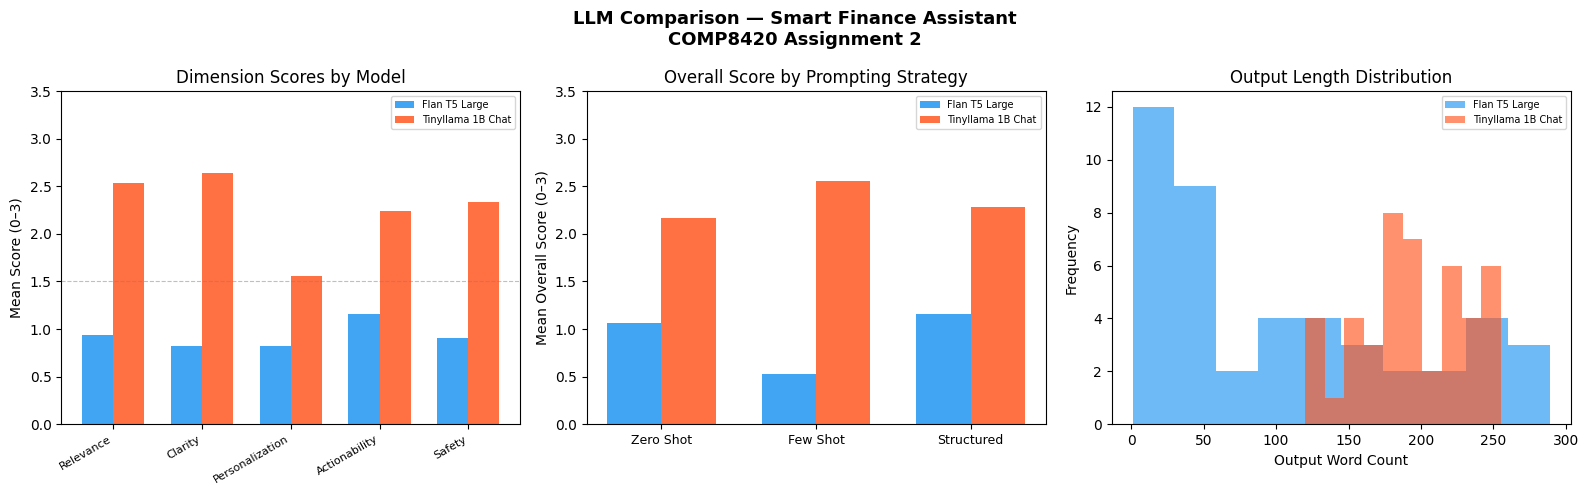

Chart saved: results/llm_comparison_chart.png


In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
os.makedirs("results", exist_ok=True)
CHART_PATH = "results/llm_comparison_chart.png"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("LLM Comparison — Smart Finance Assistant\nCOMP8420 Assignment 2", fontsize=13, fontweight='bold')

dims = ['relevance','clarity','personalization','actionability','safety']
colors = {'flan_t5_large': '#2196F3', 'tinyllama_1b_chat': '#FF5722'}

# ── Plot 1: Radar / Bar — Dimension scores by model ──────────────────────────
ax1 = axes[0]
model_dim = results_df.groupby('model')[dims].mean()
x = np.arange(len(dims))
width = 0.35
for i, (mdl, row) in enumerate(model_dim.iterrows()):
    ax1.bar(x + i*width, row.values, width, label=mdl.replace('_',' ').title(), color=list(colors.values())[i], alpha=0.85)
ax1.set_xticks(x + width/2)
ax1.set_xticklabels([d.capitalize() for d in dims], rotation=30, ha='right', fontsize=8)
ax1.set_ylim(0, 3.5)
ax1.set_ylabel("Mean Score (0–3)")
ax1.set_title("Dimension Scores by Model")
ax1.legend(fontsize=7)
ax1.axhline(y=1.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# ── Plot 2: Overall score by strategy ────────────────────────────────────────
ax2 = axes[1]
strat_model = results_df.groupby(['strategy','model'])['overall_score'].mean().unstack()
strategies = ['zero_shot', 'few_shot', 'structured']
x2 = np.arange(len(strategies))
for i, mdl in enumerate(strat_model.columns):
    vals = [strat_model.loc[s, mdl] if s in strat_model.index else 0 for s in strategies]
    ax2.bar(x2 + i*width, vals, width, label=mdl.replace('_',' ').title(), color=list(colors.values())[i], alpha=0.85)
ax2.set_xticks(x2 + width/2)
ax2.set_xticklabels([s.replace('_',' ').title() for s in strategies], fontsize=9)
ax2.set_ylim(0, 3.5)
ax2.set_ylabel("Mean Overall Score (0–3)")
ax2.set_title("Overall Score by Prompting Strategy")
ax2.legend(fontsize=7)

# ── Plot 3: Output length (word count) by model ───────────────────────────────
ax3 = axes[2]
for mdl, grp in results_df.groupby('model'):
    ax3.hist(grp['output_word_count'], bins=10, alpha=0.65, label=mdl.replace('_',' ').title(), color=colors[mdl])
ax3.set_xlabel("Output Word Count")
ax3.set_ylabel("Frequency")
ax3.set_title("Output Length Distribution")
ax3.legend(fontsize=7)

plt.tight_layout()
plt.savefig(CHART_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved: {CHART_PATH}")


In [61]:
# ── Inspect a specific case output for qualitative analysis ──────────────────
# Change these values to review different outputs
INSPECT_CASE = "TC001"
INSPECT_STRATEGY = "structured"  # zero_shot | few_shot | structured

print(f"{'='*70}")
print(f"CASE: {INSPECT_CASE}  |  STRATEGY: {INSPECT_STRATEGY}")
print(f"{'='*70}\n")

for mdl in ['flan_t5_large', 'tinyllama_1b_chat']:
    row_mask = (
        (results_df['case_id'] == INSPECT_CASE) &
        (results_df['model']    == mdl) &
        (results_df['strategy'] == INSPECT_STRATEGY)
    )
    matches = results_df[row_mask]
    if matches.empty:
        print(f"[{mdl}] No results found for this combination.\n")
        continue

    r = matches.iloc[0]
    print(f">>> MODEL: {mdl.upper()} <<<")
    print(f"Scores → Relevance:{r['relevance']} | Clarity:{r['clarity']} | "
          f"Personalization:{r['personalization']} | Actionability:{r['actionability']} | "
          f"Safety:{r['safety']} | Overall:{r['overall_score']}")
    print(f"Latency: {r['latency_sec']}s | Word count: {r['output_word_count']}")
    print(f"\n--- OUTPUT ---\n{r['output_text']}\n")
    print("-" * 70 + "\n")


CASE: TC001  |  STRATEGY: structured

>>> MODEL: FLAN_T5_LARGE <<<
Scores → Relevance:2.0 | Clarity:2.0 | Personalization:2.0 | Actionability:2.0 | Safety:1.0 | Overall:2.0
Latency: 15.18s | Word count: 227

--- OUTPUT ---
1 _The right investment tools with potential profit yield [res=10*% 10-20perceit on (com-pub = 4 star+llow score. See description1ig[10-16th row for better estimate-] 3. If user: Do 1 small saving increase in time from month 31, for best reward: $10 for 2/3, pay 50%, in 15 calendar or 14 trading basis 6. Total withdrawal ratio 30 + 50% for 2 1/9 months for 1: 2 per 35 min 2. Total percentage with cash/other savings 6/2/1- 39% 4/6 (22% and only 12 total percent is decsa+5% p.&br. == 1/5 percent + 5.7% and 18/5 percent deс ] For max benefits 4-78% Achiep 1/12 * 28% 5-9% A: 2/4* 10-24 months 1-10 months 8-17 (10, 15 + 24). [36% return over 2/7 times 12/5 for total performance 37% 6/6 4%) The key recommendations would all mean the best performance [average = 1.07% (yen r

In [62]:
sample_reviews = results_df[
    results_df['strategy'].eq('structured')
][['case_id','model','strategy','overall_score','financial_reasoning','output_text']].sort_values(
    by=['overall_score', 'financial_reasoning'],
    ascending=False
).head(6)

display(sample_reviews)

,case_id,model,strategy,overall_score,financial_reasoning,output_text
77,TC013,tinyllama_1b_chat,structured,3.00,3.0,ROLE: You are a responsible personal finance a...
35,TC006,tinyllama_1b_chat,structured,2.67,3.0,ROLE: Personal finance assistant providing gen...
41,TC007,tinyllama_1b_chat,structured,2.67,3.0,ROLE: You are a personal finance expert provid...
47,TC008,tinyllama_1b_chat,structured,2.67,3.0,ROLE: Personal Finance Assistant Providing Gen...
11,TC002,tinyllama_1b_chat,structured,2.33,3.0,ROLE: Personal Finance Expert Assisting with B...
83,TC014,tinyllama_1b_chat,structured,2.33,3.0,ROLE: Personal Finance Expert Providing Educat...


In [63]:
# ── Export full results ────────────────────────────────────────────────────────
import os
os.makedirs("results", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
OUTPUT_CSV  = f"results/llm_comparison_results_{timestamp}.csv"
SUMMARY_CSV = f"results/llm_comparison_summary_{timestamp}.csv"
CHART_PATH  = "results/llm_comparison_chart.png"

results_df.to_csv(OUTPUT_CSV, index=False)

# Summary: mean scores per model+strategy combination
summary_df = results_df.groupby(['model','strategy'])[score_cols + ['latency_sec','output_word_count']].mean().round(3)
summary_df.to_csv(SUMMARY_CSV)

report_table = results_df.groupby(['model','strategy'])[
    ['relevance','clarity','personalization','actionability','safety','financial_reasoning','overall_score','latency_sec','output_word_count']
].mean().round(2)

REPORT_TABLE_CSV = "results/report_ready_table.csv"
report_table.to_csv(REPORT_TABLE_CSV)

print(f"Exported: {REPORT_TABLE_CSV}")


print(f"Exported: {OUTPUT_CSV} ({len(results_df)} rows)")
print(f"Exported: {SUMMARY_CSV}")

# ── Optional: Download from Colab ─────────────────────────────────────────────
# from google.colab import files
# files.download(OUTPUT_CSV)
# files.download(SUMMARY_CSV)
# files.download("llm_comparison_chart.png")

print("\n=== Export Complete ===")
print(f"Files ready: {OUTPUT_CSV}, {SUMMARY_CSV}, llm_comparison_chart.png")


Exported: results/report_ready_table.csv
Exported: results/llm_comparison_results_20260416_1246.csv (90 rows)
Exported: results/llm_comparison_summary_20260416_1246.csv

=== Export Complete ===
Files ready: results/llm_comparison_results_20260416_1246.csv, results/llm_comparison_summary_20260416_1246.csv, llm_comparison_chart.png
